# Recent Hike Sensitivity For Main SSM

This notebook is an exploratory supplementary analysis for the connected-series main SSM. It checks whether adding recent fare-hike timing step dummies changes the fit, the existing event coefficients, and the trend component.

Important interpretation note: the new dummies are not interpreted as causal fare-hike effects. They are operational step dummies for level shifts around recent fare-hike timing.

Operational definitions used here:

- `recent_hike_2023_step`: 1 from 2023-04-01 onward
- `recent_hike_2024_step`: 1 from 2024-04-01 onward

The baseline is `baseline_m4`, using the same event periods as the current main connected-data analysis:

- `hike_dummy`
- `covid_main`
- `covid_wave1`
- `covid_2021`
- `post_stat_change`


In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loader import load_connected_parcel_data
from src.features import add_period_dummies
from src.forecasting.forecast_specs import get_forecast_spec
from src.ssm_models import LocalLinearTrendSeasonalWithMultiFixedExog

DATA_PATH = ROOT / "data" / "processed" / "parcel_volume_connected.csv"
SENSITIVITY_DIR = ROOT / "output" / "sensitivity"
SENSITIVITY_DIR.mkdir(parents=True, exist_ok=True)

BASE_PARAM_NAMES = [
    "obs_noise",
    "level_noise",
    "slope_noise",
    "seasonal_noise",
]
CORE_COEFFICIENTS = [
    "hike_dummy",
    "covid_main",
    "covid_wave1",
    "covid_2021",
    "post_stat_change",
]
RECENT_HIKE_DUMMIES = ["recent_hike_2023_step", "recent_hike_2024_step"]
COEFF_START_HINTS = {
    "covid_main": -2.0,
    "covid_wave1": -2.0,
    "covid_2021": -3.0,
}


## 1. Load Connected Data And Baseline Dummies

The connected monthly series is used. The model is estimated on log scale `y`, while coefficient percentage approximations are shown as `exp(coef)-1`.


In [2]:
df = load_connected_parcel_data(DATA_PATH)

baseline_spec = get_forecast_spec("baseline_m4")
baseline_periods = baseline_spec["exog_periods"]
recent_hike_periods = {
    "recent_hike_2023_step": ("2023-04-01", None),
    "recent_hike_2024_step": ("2024-04-01", None),
}

all_periods = {**baseline_periods, **recent_hike_periods}
df = add_period_dummies(df, all_periods)

active_months = []
for name in all_periods:
    active = df.index[df[name] == 1]
    active_months.append(
        {
            "dummy": name,
            "active_months": int(df[name].sum()),
            "first_active": active.min().strftime("%Y-%m-%d") if len(active) else None,
            "last_active": active.max().strftime("%Y-%m-%d") if len(active) else None,
        }
    )
active_months_df = pd.DataFrame(active_months)
active_months_df


,dummy,active_months,first_active,last_active
0,hike_dummy,27,2017-10-01,2019-12-01
1,covid_main,39,2020-03-01,2023-05-01
2,covid_wave1,2,2020-04-01,2020-05-01
3,covid_2021,9,2021-01-01,2021-09-01
4,post_stat_change,43,2022-08-01,2026-02-01
5,recent_hike_2023_step,35,2023-04-01,2026-02-01
6,recent_hike_2024_step,23,2024-04-01,2026-02-01


## 2. Model Specifications

Four specifications are compared. The baseline keeps the existing `baseline_m4` external dummy set unchanged. The added specifications include 2023, 2024, or both recent fare-hike step dummies.


In [3]:
model_specs = [
    {
        "model_id": "baseline_m4",
        "added_dummies": [],
        "note": "Existing baseline_m4 event and connection dummies",
    },
    {
        "model_id": "baseline_m4_recent_hike_2023",
        "added_dummies": ["recent_hike_2023_step"],
        "note": "Add 2023-04 onward step dummy",
    },
    {
        "model_id": "baseline_m4_recent_hike_2024",
        "added_dummies": ["recent_hike_2024_step"],
        "note": "Add 2024-04 onward step dummy",
    },
    {
        "model_id": "baseline_m4_recent_hike_2023_2024",
        "added_dummies": ["recent_hike_2023_step", "recent_hike_2024_step"],
        "note": "Add both 2023 and 2024 step dummies; reference specification",
    },
]

specs_df = pd.DataFrame(model_specs)
specs_df


,model_id,added_dummies,note
0,baseline_m4,[],Existing baseline_m4 event and connection dummies
1,baseline_m4_recent_hike_2023,[recent_hike_2023_step],Add 2023-04 onward step dummy
2,baseline_m4_recent_hike_2024,[recent_hike_2024_step],Add 2024-04 onward step dummy
3,baseline_m4_recent_hike_2023_2024,"[recent_hike_2023_step, recent_hike_2024_step]",Add both 2023 and 2024 step dummies; reference...


## 3. Estimate The Same SSM For Each Specification

The state-space structure is unchanged: local linear trend + seasonal component + fixed exogenous dummies. Only the extra recent-hike step dummies change across specifications.


In [4]:
def make_param_names(exog_names: list[str]) -> list[str]:
    return BASE_PARAM_NAMES + [f"{name}_effect" for name in exog_names]


def build_start_params(exog_names: list[str]) -> list[float]:
    init_variances = [0.01, 0.01, 0.001, 0.001]
    init_coeffs = [COEFF_START_HINTS.get(name, 0.0) for name in exog_names]
    return init_variances + init_coeffs


def fit_one_spec(model_id: str, added_dummies: list[str]) -> dict:
    exog_names = CORE_COEFFICIENTS + added_dummies
    param_names = make_param_names(exog_names)
    exog_data = [df[name] for name in exog_names]
    model = LocalLinearTrendSeasonalWithMultiFixedExog(
        endog=df["y"],
        exog_list=exog_data,
        param_names=param_names,
        seasonal_period=12,
    )

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        result = model.fit(
            start_params=build_start_params(exog_names),
            maxiter=1000,
            disp=False,
        )

    convergence_warnings = [w for w in caught if issubclass(w.category, ConvergenceWarning)]
    mle_retvals = getattr(result, "mle_retvals", {}) or {}
    params = np.asarray(result.params, dtype=float)
    bse = np.asarray(result.bse, dtype=float)
    pvalues = np.asarray(result.pvalues, dtype=float)

    trend = pd.Series(
        np.asarray(result.smoother_results.smoothed_state[0], dtype=float),
        index=df.index,
        name=model_id,
    )
    seasonal = np.asarray(result.smoother_results.smoothed_state[2], dtype=float)
    param_map = dict(zip(param_names, params))
    total_exog_effect = np.zeros(len(df), dtype=float)
    for name in exog_names:
        total_exog_effect += param_map[f"{name}_effect"] * df[name].to_numpy(dtype=float)
    fitted = trend.to_numpy(dtype=float) + seasonal + total_exog_effect
    residual = pd.Series(df["y"].to_numpy(dtype=float) - fitted, index=df.index, name=model_id)
    ljung_box = acorr_ljungbox(residual.dropna(), lags=[12], return_df=True)

    coefficients = []
    for name, estimate, std_error, p_value in zip(param_names, params, bse, pvalues):
        variable = name.removesuffix("_effect") if name.endswith("_effect") else name
        coefficients.append(
            {
                "model_id": model_id,
                "parameter": name,
                "variable": variable,
                "estimate": float(estimate),
                "std_error": float(std_error),
                "p_value": float(p_value),
                "approx_percent": float(np.exp(estimate) - 1.0) if name.endswith("_effect") else np.nan,
            }
        )

    return {
        "result": result,
        "param_names": param_names,
        "exog_names": exog_names,
        "trend": trend,
        "residual": residual,
        "coefficients": coefficients,
        "summary": {
            "model_id": model_id,
            "added_dummies": ",".join(added_dummies) if added_dummies else "none",
            "status": "success",
            "error": "",
            "nobs": int(result.nobs),
            "log_likelihood": float(result.llf),
            "aic": float(result.aic),
            "bic": float(result.bic),
            "converged": bool(mle_retvals.get("converged", False)),
            "warnflag": mle_retvals.get("warnflag", np.nan),
            "convergence_warning": bool(convergence_warnings),
            "warning_messages": " | ".join(str(w.message) for w in convergence_warnings),
            "ljung_box_pvalue_lag12": float(ljung_box["lb_pvalue"].iloc[0]),
        },
    }


fit_outputs = {}
summary_rows = []
coefficient_rows = []
trend_by_model = {}
residual_by_model = {}

for spec in model_specs:
    model_id = spec["model_id"]
    print(f"Estimating {model_id} ...")
    try:
        output = fit_one_spec(model_id, spec["added_dummies"])
        fit_outputs[model_id] = output
        summary_rows.append(output["summary"])
        coefficient_rows.extend(output["coefficients"])
        trend_by_model[model_id] = output["trend"]
        residual_by_model[model_id] = output["residual"]
    except Exception as exc:
        summary_rows.append(
            {
                "model_id": model_id,
                "added_dummies": ",".join(spec["added_dummies"]) if spec["added_dummies"] else "none",
                "status": "failed",
                "error": f"{type(exc).__name__}: {exc}",
                "nobs": np.nan,
                "log_likelihood": np.nan,
                "aic": np.nan,
                "bic": np.nan,
                "converged": False,
                "warnflag": np.nan,
                "convergence_warning": False,
                "warning_messages": "",
                "ljung_box_pvalue_lag12": np.nan,
            }
        )

comparison_df = pd.DataFrame(summary_rows)
coefficients_df = pd.DataFrame(coefficient_rows)
comparison_df


Estimating baseline_m4 ...


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Estimating baseline_m4_recent_hike_2023 ...


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Estimating baseline_m4_recent_hike_2024 ...


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Estimating baseline_m4_recent_hike_2023_2024 ...


C:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,model_id,added_dummies,status,error,nobs,log_likelihood,aic,bic,converged,warnflag,convergence_warning,warning_messages,ljung_box_pvalue_lag12
0,baseline_m4,none,success,,287,584.069437,-1124.138874,-1043.630265,True,0,False,,2.192728e-07
1,baseline_m4_recent_hike_2023,recent_hike_2023_step,success,,287,584.173880,-1122.347761,-1038.179670,True,0,False,,1.848893e-07
2,baseline_m4_recent_hike_2024,recent_hike_2024_step,success,,287,584.080263,-1122.160527,-1037.992436,True,0,False,,2.026757e-07
3,baseline_m4_recent_hike_2023_2024,"recent_hike_2023_step,recent_hike_2024_step",success,,287,584.182022,-1120.364044,-1032.536471,False,2,True,Maximum Likelihood optimization failed to conv...,2.149349e-07


## 4. Fit Comparison

This table summarizes information criteria, convergence information, and Ljung-Box p-values.


In [5]:
display_cols = [
    "model_id",
    "added_dummies",
    "status",
    "log_likelihood",
    "aic",
    "bic",
    "converged",
    "warnflag",
    "convergence_warning",
    "ljung_box_pvalue_lag12",
]
comparison_df[display_cols]


,model_id,added_dummies,status,log_likelihood,aic,bic,converged,warnflag,convergence_warning,ljung_box_pvalue_lag12
0,baseline_m4,none,success,584.069437,-1124.138874,-1043.630265,True,0,False,2.192728e-07
1,baseline_m4_recent_hike_2023,recent_hike_2023_step,success,584.173880,-1122.347761,-1038.179670,True,0,False,1.848893e-07
2,baseline_m4_recent_hike_2024,recent_hike_2024_step,success,584.080263,-1122.160527,-1037.992436,True,0,False,2.026757e-07
3,baseline_m4_recent_hike_2023_2024,"recent_hike_2023_step,recent_hike_2024_step",success,584.182022,-1120.364044,-1032.536471,False,2,True,2.149349e-07


## 5. Coefficient Stability

The table focuses on the existing baseline coefficients and the newly added recent-hike coefficients. `approx_percent` is `exp(coef)-1`, so it should be read as an approximate level difference on the original scale, not as a causal effect.


In [6]:
key_variables = CORE_COEFFICIENTS + RECENT_HIKE_DUMMIES
coef_display = coefficients_df[coefficients_df["variable"].isin(key_variables)].copy()
coef_display["approx_percent"] = 100 * coef_display["approx_percent"]
coef_display = coef_display.sort_values(["variable", "model_id"])
coef_display[["model_id", "variable", "estimate", "std_error", "p_value", "approx_percent"]]


,model_id,variable,estimate,std_error,p_value,approx_percent
7,baseline_m4,covid_2021,0.016180,0.012627,0.200056,1.631127
16,baseline_m4_recent_hike_2023,covid_2021,0.016048,0.012693,0.206114,1.617712
36,baseline_m4_recent_hike_2023_2024,covid_2021,0.015988,0.012703,0.208180,1.611650
26,baseline_m4_recent_hike_2024,covid_2021,0.016247,0.012683,0.200188,1.637948
5,baseline_m4,covid_main,0.030467,0.018648,0.102304,3.093559
14,baseline_m4_recent_hike_2023,covid_main,0.027527,0.019623,0.160676,2.790914
34,baseline_m4_recent_hike_2023_2024,covid_main,0.027628,0.020021,0.167604,2.801274
24,baseline_m4_recent_hike_2024,covid_main,0.030643,0.019120,0.109000,3.111733
6,baseline_m4,covid_wave1,0.051196,0.017872,0.004176,5.252939
15,baseline_m4_recent_hike_2023,covid_wave1,0.051651,0.017291,0.002816,5.300807


## 6. Trend Comparison

The trend components are compared across the baseline and recent-hike specifications. The goal is to see whether the added step dummies force implausible changes in the latent trend.


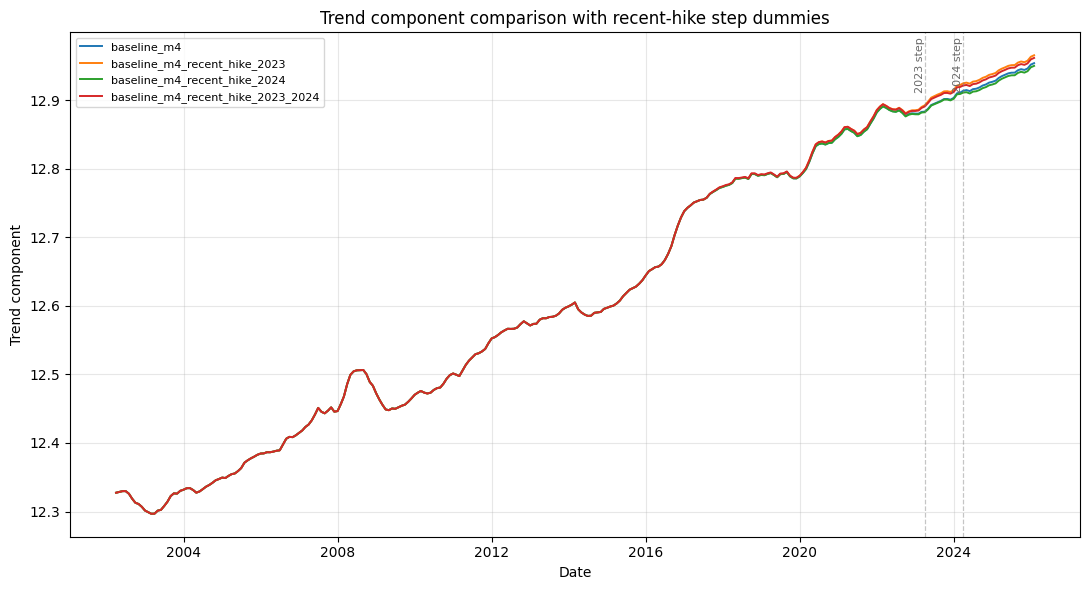

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
for spec in model_specs:
    model_id = spec["model_id"]
    if model_id in trend_by_model:
        ax.plot(trend_by_model[model_id].index, trend_by_model[model_id], linewidth=1.4, label=model_id)

for marker_date, label in [(pd.Timestamp("2023-04-01"), "2023 step"), (pd.Timestamp("2024-04-01"), "2024 step")]:
    ax.axvline(marker_date, color="gray", linestyle="--", linewidth=0.9, alpha=0.45)
    ax.text(marker_date, 0.99, label, transform=ax.get_xaxis_transform(), rotation=90, va="top", ha="right", fontsize=8, color="dimgray")

ax.set_title("Trend component comparison with recent-hike step dummies")
ax.set_xlabel("Date")
ax.set_ylabel("Trend component")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "recent_hike_trends.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Save Outputs


In [8]:
comparison_path = SENSITIVITY_DIR / "recent_hike_model_comparison.csv"
coefficients_path = SENSITIVITY_DIR / "recent_hike_coefficients.csv"
trend_path = SENSITIVITY_DIR / "recent_hike_trends.png"

comparison_df.to_csv(comparison_path, index=False)
coefficients_df.to_csv(coefficients_path, index=False)

print(f"saved {comparison_path}")
print(f"saved {coefficients_path}")
print(f"saved {trend_path}")


saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\recent_hike_model_comparison.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\recent_hike_coefficients.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\recent_hike_trends.png


## 8. Reading Notes

- The recent-hike dummies are step dummies for level shifts around specified timing. They are not causal fare-hike effects.
- If the new dummy coefficients are unstable or have large standard errors, that is consistent with overlap with `post_stat_change` and the late-sample trend.
- The key diagnostic is whether the existing coefficients, especially `covid_main`, `covid_wave1`, `covid_2021`, and `post_stat_change`, remain qualitatively stable after adding the recent-hike dummies.
- The both-dummy specification is a reference check and may be harder to interpret because the 2023 and 2024 step dummies are nested with the post-2022 connection dummy.


## 9. Decomposition Plots For Baseline And Recent-Hike Specifications

The following figures follow the existing SSM decomposition style used in the earlier analysis notebooks: observed vs. fitted values, trend, seasonal component, external event effects, and residuals.

Here the plots are split into separate files so that `baseline_m4` and the recent-hike supplementary specifications can be compared more directly. The recent-hike step dummies are still interpreted only as timing-based level-shift controls, not as causal price-hike effects.


In [9]:
def compute_components_for_output(output: dict) -> dict:
    result = output["result"]
    param_names = output["param_names"]
    exog_names = output["exog_names"]
    param_map = dict(zip(param_names, np.asarray(result.params, dtype=float)))

    trend = np.asarray(result.smoother_results.smoothed_state[0], dtype=float)
    seasonal = np.asarray(result.smoother_results.smoothed_state[2], dtype=float)

    effects = {}
    total_exog_effect = np.zeros(len(df), dtype=float)
    for exog_name in exog_names:
        param_name = f"{exog_name}_effect"
        effect = param_map[param_name] * df[exog_name].to_numpy(dtype=float)
        effects[exog_name] = effect
        total_exog_effect += effect

    fitted = trend + seasonal + total_exog_effect
    residual = df["y"].to_numpy(dtype=float) - fitted
    return {
        "trend": trend,
        "seasonal": seasonal,
        "effects": effects,
        "total_exog_effect": total_exog_effect,
        "fitted": fitted,
        "residual": residual,
    }


decomposition_by_model = {
    model_id: compute_components_for_output(output)
    for model_id, output in fit_outputs.items()
}

plot_model_ids = [spec["model_id"] for spec in model_specs if spec["model_id"] in decomposition_by_model]
plot_model_ids


['baseline_m4',
 'baseline_m4_recent_hike_2023',
 'baseline_m4_recent_hike_2024',
 'baseline_m4_recent_hike_2023_2024']

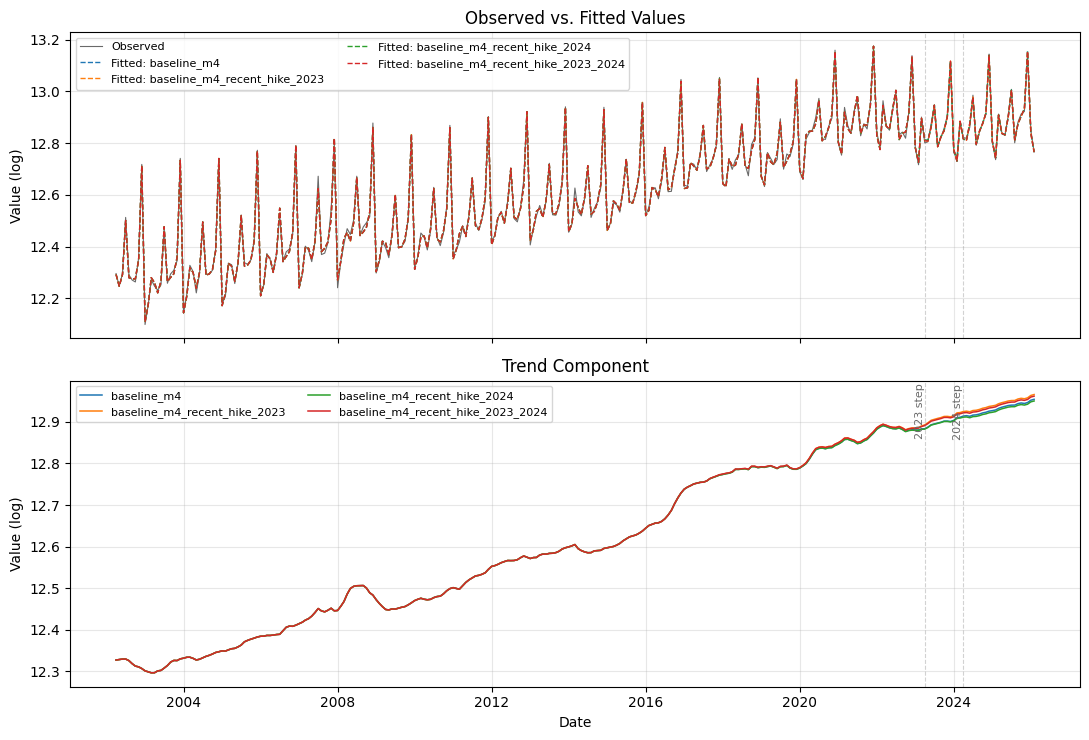

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(11, 7.5), sharex=True)

axes[0].plot(df.index, df["y"], color="dimgray", linewidth=0.8, label="Observed")
for model_id in plot_model_ids:
    axes[0].plot(
        df.index,
        decomposition_by_model[model_id]["fitted"],
        linestyle="--",
        linewidth=1.0,
        label=f"Fitted: {model_id}",
    )
axes[0].set_title("Observed vs. Fitted Values")
axes[0].set_ylabel("Value (log)")
axes[0].legend(loc="upper left", fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)

for model_id in plot_model_ids:
    axes[1].plot(
        df.index,
        decomposition_by_model[model_id]["trend"],
        linewidth=1.1,
        label=model_id,
    )
axes[1].set_title("Trend Component")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Value (log)")
axes[1].legend(loc="upper left", fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)

for marker_date, label in [(pd.Timestamp("2023-04-01"), "2023 step"), (pd.Timestamp("2024-04-01"), "2024 step")]:
    for ax in axes:
        ax.axvline(marker_date, color="gray", linestyle="--", linewidth=0.8, alpha=0.35)
    axes[1].text(marker_date, 0.99, label, transform=axes[1].get_xaxis_transform(), rotation=90, va="top", ha="right", fontsize=8, color="dimgray")

fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "recent_hike_decomposition_main.png", dpi=300, bbox_inches="tight")
plt.show()


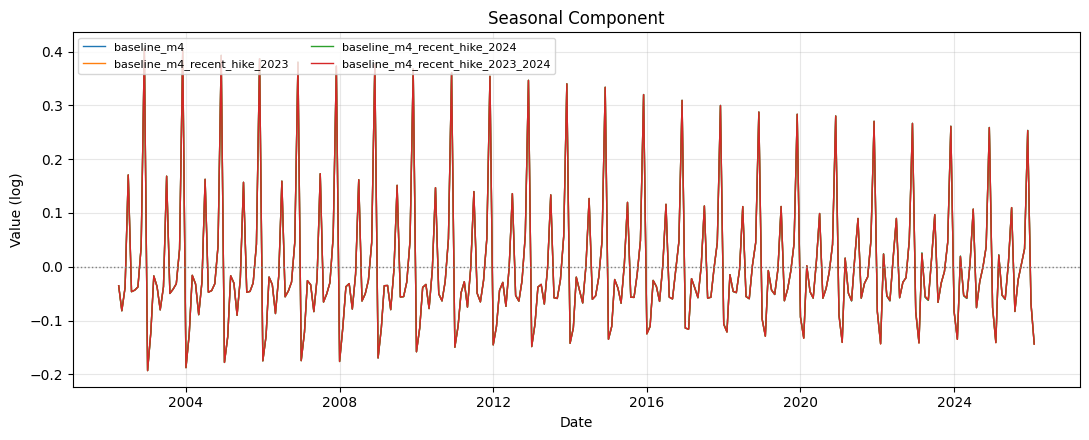

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for model_id in plot_model_ids:
    ax.plot(
        df.index,
        decomposition_by_model[model_id]["seasonal"],
        linewidth=1.0,
        label=model_id,
    )
ax.axhline(y=0, color="grey", linestyle=":", linewidth=1.0)
ax.set_title("Seasonal Component")
ax.set_xlabel("Date")
ax.set_ylabel("Value (log)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "recent_hike_decomposition_seasonal.png", dpi=300, bbox_inches="tight")
plt.show()


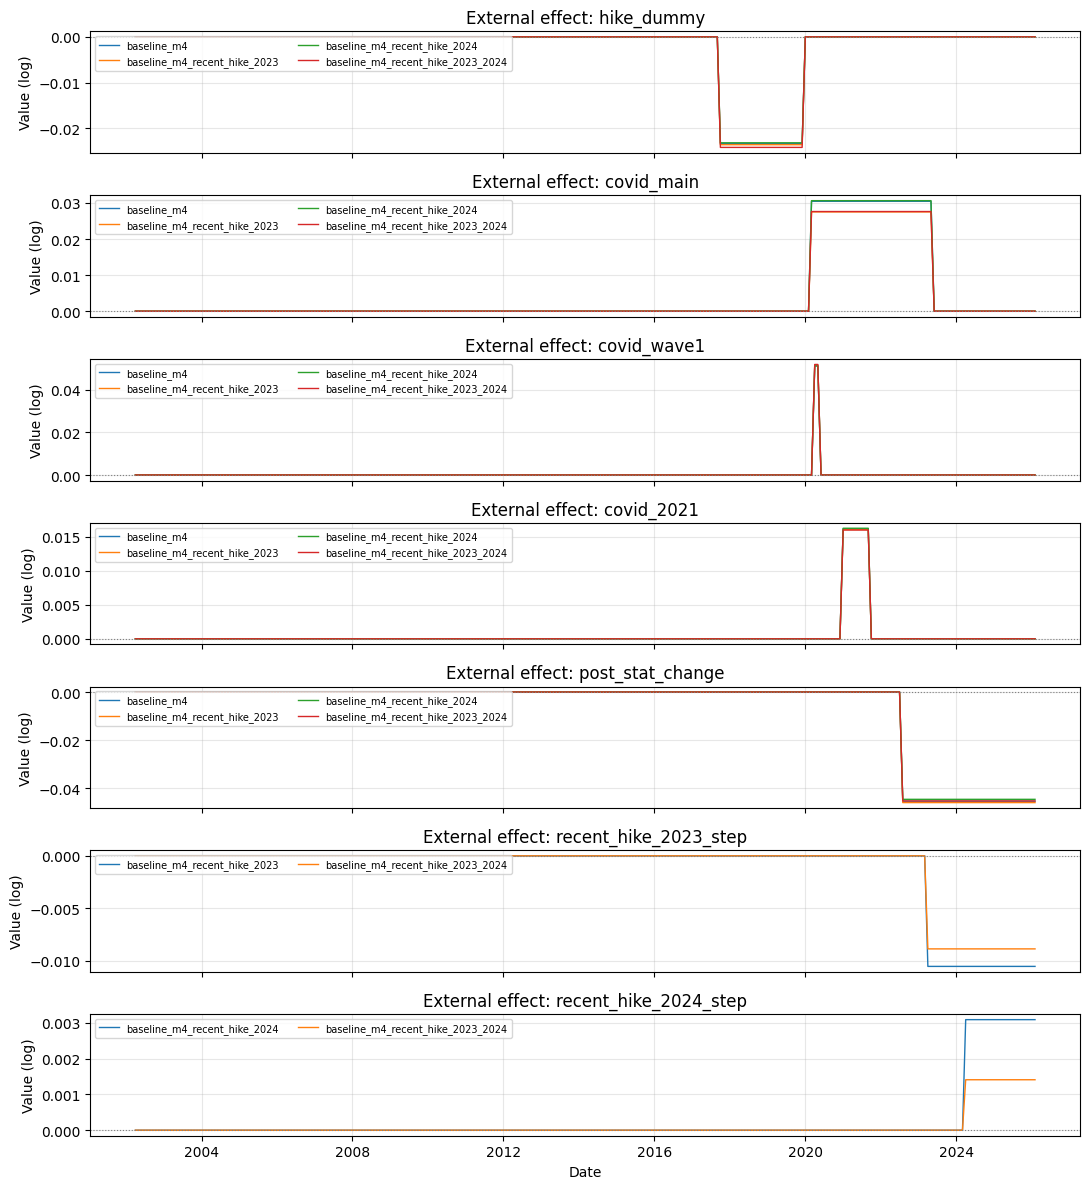

In [12]:
effect_order = CORE_COEFFICIENTS + RECENT_HIKE_DUMMIES
fig, axes = plt.subplots(nrows=len(effect_order), ncols=1, figsize=(11, 12), sharex=True)

for ax, exog_name in zip(axes, effect_order):
    plotted = False
    for model_id in plot_model_ids:
        effects = decomposition_by_model[model_id]["effects"]
        if exog_name in effects:
            ax.plot(df.index, effects[exog_name], linewidth=1.0, label=model_id)
            plotted = True
    ax.axhline(y=0, color="grey", linestyle=":", linewidth=0.8)
    ax.set_title(f"External effect: {exog_name}")
    ax.set_ylabel("Value (log)")
    ax.grid(True, alpha=0.3)
    if plotted:
        ax.legend(loc="upper left", fontsize=7, ncol=2)

axes[-1].set_xlabel("Date")
fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "recent_hike_decomposition_exog.png", dpi=300, bbox_inches="tight")
plt.show()


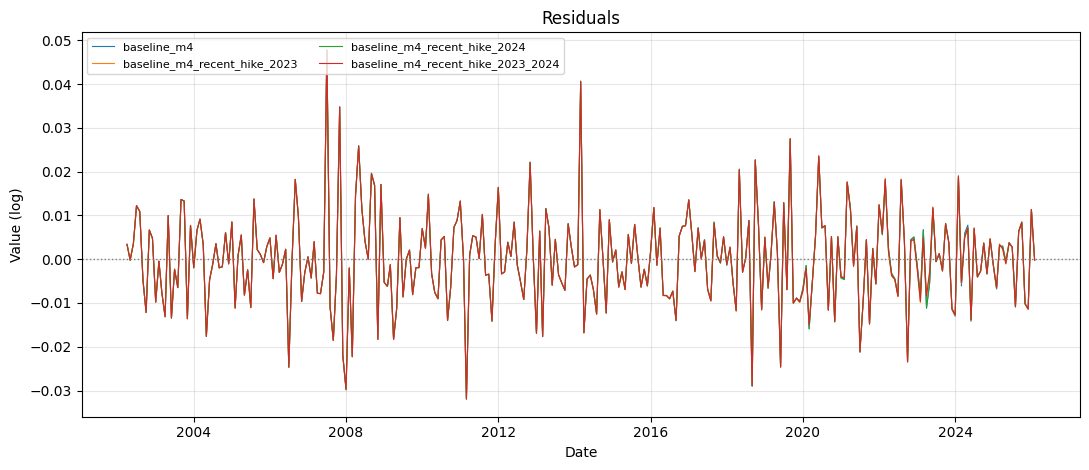

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.8))
for model_id in plot_model_ids:
    ax.plot(
        df.index,
        decomposition_by_model[model_id]["residual"],
        linewidth=0.8,
        label=model_id,
    )
ax.axhline(y=0, color="grey", linestyle=":", linewidth=1.0)
ax.set_title("Residuals")
ax.set_xlabel("Date")
ax.set_ylabel("Value (log)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "recent_hike_decomposition_residuals.png", dpi=300, bbox_inches="tight")
plt.show()


In [14]:
decomposition_paths = [
    SENSITIVITY_DIR / "recent_hike_decomposition_main.png",
    SENSITIVITY_DIR / "recent_hike_decomposition_seasonal.png",
    SENSITIVITY_DIR / "recent_hike_decomposition_exog.png",
    SENSITIVITY_DIR / "recent_hike_decomposition_residuals.png",
]
for path in decomposition_paths:
    print(f"saved {path}")


saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\recent_hike_decomposition_main.png
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\recent_hike_decomposition_seasonal.png
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\recent_hike_decomposition_exog.png
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity\recent_hike_decomposition_residuals.png


## 10. How To Read The Decomposition Figures

- `recent_hike_decomposition_main.png` compares the observed log series, fitted values, and trend component. If the recent-hike specifications mainly shift fitted values without forcing a large change in the latent trend, the trend lines should remain close.
- `recent_hike_decomposition_seasonal.png` compares the seasonal components. Large differences here would indicate that the added step dummies are changing the seasonal decomposition, not just the late-period level.
- `recent_hike_decomposition_exog.png` shows each external-variable contribution. The recent-hike step effects appear only in the specifications that include those dummies.
- `recent_hike_decomposition_residuals.png` compares residuals across specifications. This is useful for checking whether the added dummies visibly reduce late-period residuals, while remembering that Ljung-Box p-values still indicated residual autocorrelation.
